NQS Day 1 
======================================

Requirements:
numpy, scipy, matplotlib, torch
(Install with: pip install numpy scipy matplotlib torch)

In [1]:
import numpy as np
from scipy import sparse
from scipy.sparse import linalg as spla
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import eigsh

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim

import itertools, time

## Problem 1.1 Background

We will use ED code to find the grounstate of the 1D TFI model for a chain of N spins. For $h<J$, $h=J$, $h>J$. 

### The Hamiltionian:
$$ H = - J \sum_i \sigma_i^z \sigma_{i+1}^z - h \sum_i \sigma_i^x $$

In [2]:
"""
Exact Diagonalization (ED) of the 1D Transverse Field Ising (TFI) Model

    H = -J * sum_i sigma_i^z sigma_{i+1}^z  -  h * sum_i sigma_i^x

Basis: computational basis |s_0, s_1, ..., s_{N-1}> where s_i in {0,1}
  |0> = spin-up   (+1 eigenvalue of sigma^z)
  |1> = spin-down (-1 eigenvalue of sigma^z)

Periodic boundary conditions (PBC) are used by default.

Phase diagram (N -> infinity):
  h < J : ferromagnetic (Z2-broken) phase
  h = J : critical point (CFT: Ising universality class, c=1/2)
  h > J : paramagnetic (disordered) phase
"""

# Hamiltonian construction

def build_hamiltonian(N: int, J: float, h: float, pbc: bool = True):
    """
    Build the TFI Hamiltonian as a sparse matrix in the 2^N computational basis.

    Parameters
    ----------
    N   : number of spins
    J   : Ising coupling  (J > 0 → ferromagnetic)
    h   : transverse field strength
    pbc : periodic boundary conditions

    Returns
    -------
    H : scipy csr_matrix of shape (2^N, 2^N)
    """
    dim = 2 ** N
    H = lil_matrix((dim, dim), dtype=float)

    for state in range(dim):
        # ── sigma^z_i sigma^z_{i+1} (diagonal) ──────────────────────────────
        for i in range(N - 1):
            si = (state >> i) & 1      # bit i  (0=up, 1=down)
            sj = (state >> (i+1)) & 1  # bit i+1
            sz_i = 1 - 2 * si          # maps {0,1} -> {+1,-1} needed for sigma^z eigenvalues
            sz_j = 1 - 2 * sj
            H[state, state] -= J * sz_i * sz_j

        if pbc:
            # wrap-around bond: spin N-1 ↔ spin 0
            # TODO implement periodic boundary conditions
            s0 = (state >> (N - 1)) & 1
            sN = (state >> 0) & 1
            sz0 = 1 - 2 * s0
            szN = 1 - 2 * sN
            H[state, state] -= J * sz0 * szN

        # ── sigma^x_i (off-diagonal: flips bit i) ───────────────────────────
        for i in range(N):
            # TODO implement off-diagonal elements
            flipped = state ^ (1 << i)  # flip bit i
            H[state, flipped] -= h           
    return csr_matrix(H)


# Observables

def magnetization_z(psi: np.ndarray, N: int) -> float:
    """
    <psi| (1/N) sum_i sigma^z_i |psi>
    Measures ferromagnetic order parameter.
    """
    dim = 2 ** N
    m = 0.0
    for state in range(dim):
        amp2 = abs(psi[state]) ** 2         # probability of being in this basis state
        sz_total = sum(1 - 2 * ((state >> i) & 1) for i in range(N))    # total magnetization of this basis state
        m += amp2 * sz_total    # weighted contribution to magnetization
    return m / N


def magnetization_x(psi: np.ndarray, N: int) -> float:
    """
    <psi| (1/N) sum_i sigma^x_i |psi>
    Measures paramagnetic order parameter.
    """
    dim = 2 ** N
    mx = 0.0
    for state in range(dim):
        for i in range(N):
            flipped = state ^ (1 << i) # flip bit i
            mx += psi[state].conj() * psi[flipped]  # contribution from flipping spin i in this basis state
    return (mx / N).real


def energy_density(E0: float, N: int) -> float:
    return E0 / N


# Main solver

def solve_tfi(N: int, J: float, h: float, pbc: bool = True, n_states: int = 4):
    """
    Solve for the lowest n_states eigenstates of the TFI model.

    Returns
    -------
    energies : ndarray of shape (n_states,)
    states   : ndarray of shape (2^N, n_states)
    gap      : first excitation gap E1 - E0
    """
    H = build_hamiltonian(N, J, h, pbc)
    # eigsh returns eigenvalues in ascending order
    n_eig = min(n_states, 2**N)    # can't request more eigenvalues than the dimension of the Hilbert space
    energies, states = eigsh(H, k=n_eig, which='SA') # 'SA' = smallest algebraic
    idx = np.argsort(energies)  
    energies = energies[idx]
    states = states[:, idx]
    gap = energies[1] - energies[0] if n_eig > 1 else None
    return energies, states, gap


## Auxiliary cells

### Solve the model for a 2x2 system analytically to verify correctness of the implementation

In [3]:
s_x = np.array([[0, 1], [1, 0]])  
s_z = np.array([[1, 0], [0, -1]])
id = np.eye(2)

J_small = 0
h_small = 1

H_analitical = -J_small * np.kron(s_z, s_z) - h_small * (np.kron(s_x, id) + np.kron(id, s_x))
print("Analytical Hamiltonian:\n", H_analitical)

Analytical Hamiltonian:
 [[ 0. -1. -1.  0.]
 [-1.  0.  0. -1.]
 [-1.  0.  0. -1.]
 [ 0. -1. -1.  0.]]


In [4]:
H = build_hamiltonian(N=2, J=0, h=1, pbc=False)
print("Numerical Hamiltonian:\n", H.todense())

Numerical Hamiltonian:
 [[ 0. -1. -1.  0.]
 [-1.  0.  0. -1.]
 [-1.  0.  0. -1.]
 [ 0. -1. -1.  0.]]


### Do the same for 3x3 system analytically to verify correctness of the implementation

In [5]:
# 3x3 matrix 
id3 = np.eye(3)
s_z_3 = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]])
s_x_3 = np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]])

H_analitical_3x3 = J_small * np.kron(s_z_3, s_z_3) - h_small * (np.kron(s_x_3, id3) + np.kron(id3, s_x_3))
print("Analytical 3x3 Hamiltonian:\n", H_analitical_3x3)

Analytical 3x3 Hamiltonian:
 [[ 0. -1.  0. -1.  0.  0.  0.  0.  0.]
 [-1.  0. -1.  0. -1.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0. -1.  0.  0.  0.]
 [-1.  0.  0.  0. -1.  0. -1.  0.  0.]
 [ 0. -1.  0. -1.  0. -1.  0. -1.  0.]
 [ 0.  0. -1.  0. -1.  0.  0.  0. -1.]
 [ 0.  0.  0. -1.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0. -1.  0. -1.  0. -1.]
 [ 0.  0.  0.  0.  0. -1.  0. -1.  0.]]


In [6]:
H = build_hamiltonian(N=3, J=0, h=1, pbc=False)
print("Numerical Hamiltonian:\n", H.todense())

Numerical Hamiltonian:
 [[ 0. -1. -1.  0. -1.  0.  0.  0.]
 [-1.  0.  0. -1.  0. -1.  0.  0.]
 [-1.  0.  0. -1.  0.  0. -1.  0.]
 [ 0. -1. -1.  0.  0.  0.  0. -1.]
 [-1.  0.  0.  0.  0. -1. -1.  0.]
 [ 0. -1.  0.  0. -1.  0.  0. -1.]
 [ 0.  0. -1.  0. -1.  0.  0. -1.]
 [ 0.  0.  0. -1.  0. -1. -1.  0.]]


### Try some Hamiltonians with different parameters to see if our interpretation is correct:

In [7]:
H = build_hamiltonian(N=4, J=0, h=1, pbc=False)
print("Hamiltonian:\n", H.todense())

Hamiltonian:
 [[ 0. -1. -1.  0. -1.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  0.  0. -1.  0. -1.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.]
 [-1.  0.  0. -1.  0.  0. -1.  0.  0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0. -1. -1.  0.  0.  0.  0. -1.  0.  0.  0. -1.  0.  0.  0.  0.]
 [-1.  0.  0.  0.  0. -1. -1.  0.  0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0. -1.  0.  0. -1.  0.  0. -1.  0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0. -1.  0. -1.  0.  0. -1.  0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0. -1.  0. -1. -1.  0.  0.  0.  0.  0.  0.  0.  0. -1.]
 [-1.  0.  0.  0.  0.  0.  0.  0.  0. -1. -1.  0. -1.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0. -1.  0.  0. -1.  0. -1.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.  0. -1. -1.  0.  0.  0.  0. -1.]
 [ 0.  0.  0.  0. -1.  0.  0.  0. -1.  0.  0.  0.  0. -1. -1.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.  0. -1.  0.  0. -1.  0.  0. -1.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.  0.  0. -1.  0

In [8]:
H = build_hamiltonian(N=4, J=0, h=2, pbc=False)
print("Hamiltonian:\n", H.todense())

Hamiltonian:
 [[ 0. -2. -2.  0. -2.  0.  0.  0. -2.  0.  0.  0.  0.  0.  0.  0.]
 [-2.  0.  0. -2.  0. -2.  0.  0.  0. -2.  0.  0.  0.  0.  0.  0.]
 [-2.  0.  0. -2.  0.  0. -2.  0.  0.  0. -2.  0.  0.  0.  0.  0.]
 [ 0. -2. -2.  0.  0.  0.  0. -2.  0.  0.  0. -2.  0.  0.  0.  0.]
 [-2.  0.  0.  0.  0. -2. -2.  0.  0.  0.  0.  0. -2.  0.  0.  0.]
 [ 0. -2.  0.  0. -2.  0.  0. -2.  0.  0.  0.  0.  0. -2.  0.  0.]
 [ 0.  0. -2.  0. -2.  0.  0. -2.  0.  0.  0.  0.  0.  0. -2.  0.]
 [ 0.  0.  0. -2.  0. -2. -2.  0.  0.  0.  0.  0.  0.  0.  0. -2.]
 [-2.  0.  0.  0.  0.  0.  0.  0.  0. -2. -2.  0. -2.  0.  0.  0.]
 [ 0. -2.  0.  0.  0.  0.  0.  0. -2.  0.  0. -2.  0. -2.  0.  0.]
 [ 0.  0. -2.  0.  0.  0.  0.  0. -2.  0.  0. -2.  0.  0. -2.  0.]
 [ 0.  0.  0. -2.  0.  0.  0.  0.  0. -2. -2.  0.  0.  0.  0. -2.]
 [ 0.  0.  0.  0. -2.  0.  0.  0. -2.  0.  0.  0.  0. -2. -2.  0.]
 [ 0.  0.  0.  0.  0. -2.  0.  0.  0. -2.  0.  0. -2.  0.  0. -2.]
 [ 0.  0.  0.  0.  0.  0. -2.  0.  0.  0. -2.  0

In [9]:
H = build_hamiltonian(N=4, J=2, h=2, pbc=False)
print("Hamiltonian:\n", H.todense())

Hamiltonian:
 [[-6. -2. -2.  0. -2.  0.  0.  0. -2.  0.  0.  0.  0.  0.  0.  0.]
 [-2. -2.  0. -2.  0. -2.  0.  0.  0. -2.  0.  0.  0.  0.  0.  0.]
 [-2.  0.  2. -2.  0.  0. -2.  0.  0.  0. -2.  0.  0.  0.  0.  0.]
 [ 0. -2. -2. -2.  0.  0.  0. -2.  0.  0.  0. -2.  0.  0.  0.  0.]
 [-2.  0.  0.  0.  2. -2. -2.  0.  0.  0.  0.  0. -2.  0.  0.  0.]
 [ 0. -2.  0.  0. -2.  6.  0. -2.  0.  0.  0.  0.  0. -2.  0.  0.]
 [ 0.  0. -2.  0. -2.  0.  2. -2.  0.  0.  0.  0.  0.  0. -2.  0.]
 [ 0.  0.  0. -2.  0. -2. -2. -2.  0.  0.  0.  0.  0.  0.  0. -2.]
 [-2.  0.  0.  0.  0.  0.  0.  0. -2. -2. -2.  0. -2.  0.  0.  0.]
 [ 0. -2.  0.  0.  0.  0.  0.  0. -2.  2.  0. -2.  0. -2.  0.  0.]
 [ 0.  0. -2.  0.  0.  0.  0.  0. -2.  0.  6. -2.  0.  0. -2.  0.]
 [ 0.  0.  0. -2.  0.  0.  0.  0.  0. -2. -2.  2.  0.  0.  0. -2.]
 [ 0.  0.  0.  0. -2.  0.  0.  0. -2.  0.  0.  0. -2. -2. -2.  0.]
 [ 0.  0.  0.  0.  0. -2.  0.  0.  0. -2.  0.  0. -2.  2.  0. -2.]
 [ 0.  0.  0.  0.  0.  0. -2.  0.  0.  0. -2.  0

## Back to Problem 1.1

In [10]:
# Demonstration: three regimes + phase diagram scan

def demo(N: int = 8):
    J = 1.0
    regimes = [
        ("h < J  (ferromagnetic)",  0.3 * J),
        ("h = J  (critical)",       1.0 * J),
        ("h > J  (paramagnetic)",   3.0 * J),
    ]

    print("=" * 62) 
    print(f"  TFI Exact Diagonalization   N = {N},  PBC")
    print(f"  H = -J Σ σᶻᵢσᶻᵢ₊₁ - h Σ σˣᵢ   (J = {J})")
    print("=" * 62)

    results = []
    for label, h in regimes:
        energies, states, gap = solve_tfi(N, J, h, pbc=True, n_states=6)
        gs = states[:, 0]
        mz  = abs(magnetization_z(gs, N))
        mx  = abs(magnetization_x(gs, N))
        e0  = energy_density(energies[0], N)

        results.append(dict(label=label, h=h, energies=energies,
                            gap=gap, mz=mz, mx=mx, e0=e0))

        print(f"\n── {label} ──")
        print(f"   h/J = {h/J:.2f}")
        print(f"   E0/N          = {e0:.6f}")
        print(f"   Gap (E1-E0)   = {gap:.6f}")
        print(f"   |<σᶻ>|        = {mz:.6f}  (ferro order param)")
        print(f"   |<σˣ>|        = {mx:.6f}  (para  order param)")
        print(f"   Lowest 6 E's  = {energies[:6]}")

    # ── phase diagram scan ───────────────────────────────────────────────────
    h_vals = np.linspace(0.1, 3.0, 50)
    gaps, mzs, mxs = [], [], []
    for h in h_vals:
        energies, states, gap = solve_tfi(N, J, h, pbc=True, n_states=4)
        gs = states[:, 0]
        gaps.append(gap)
        mzs.append(abs(magnetization_z(gs, N)))
        mxs.append(abs(magnetization_x(gs, N)))

    # ── plot ─────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 9))
    fig.suptitle(
        f"TFI Model — Exact Diagonalization  (N = {N}, PBC, J = {J})",
        fontsize=14, fontweight='bold', y=0.97
    )
    gs_fig = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

    colors = ['#2563eb', '#dc2626', '#16a34a']

    # ── top row: spectrum for three regimes ──────────────────────────────────
    for col, (res, c) in enumerate(zip(results, colors)):
        ax = fig.add_subplot(gs_fig[0, col])
        levels = res['energies'][:6]
        for i, E in enumerate(levels):
            lw = 2.5 if i == 0 else 1.2
            alpha = 1.0 if i == 0 else 0.55
            ax.hlines(E, 0.2, 0.8, linewidth=lw, color=c, alpha=alpha)
        ax.set_xlim(0, 1)
        ax.set_xticks([])
        ax.set_ylabel('Energy', fontsize=10)
        ax.set_title(
            f"h/J = {res['h']/J:.1f}\n"
            f"{'Ferromagnet' if res['h'] < J else ('Critical' if res['h'] == J else 'Paramagnet')}",
            fontsize=10
        )
        ax.annotate(
            f"gap = {res['gap']:.3f}",
            xy=(0.5, levels[0] + (levels[1]-levels[0])*0.3),
            ha='center', fontsize=8, color=c
        )
        ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.5)

    # ── bottom-left: gap vs h/J ───────────────────────────────────────────────
    ax1 = fig.add_subplot(gs_fig[1, 0])
    ax1.plot(h_vals / J, gaps, 'k-', linewidth=1.8)
    ax1.axvline(1.0, color='#dc2626', linestyle='--', linewidth=1.2, label='h = J (critical)')
    ax1.set_xlabel('h / J', fontsize=11)
    ax1.set_ylabel('Gap  E₁ − E₀', fontsize=11)
    ax1.set_title('Spectral gap', fontsize=11)
    ax1.legend(fontsize=8)
    ax1.grid(linestyle=':', alpha=0.5)

    # ── bottom-center: order parameters ─────────────────────────────────────
    ax2 = fig.add_subplot(gs_fig[1, 1])
    ax2.plot(h_vals / J, mzs, color='#2563eb', linewidth=1.8, label='|⟨σᶻ⟩| ferro')
    ax2.plot(h_vals / J, mxs, color='#16a34a', linewidth=1.8, label='|⟨σˣ⟩| para')
    ax2.axvline(1.0, color='#dc2626', linestyle='--', linewidth=1.2, label='h = J')
    ax2.set_xlabel('h / J', fontsize=11)
    ax2.set_ylabel('Order parameter', fontsize=11)
    ax2.set_title('Order parameters', fontsize=11)
    ax2.legend(fontsize=8)
    ax2.grid(linestyle=':', alpha=0.5)

    # ── bottom-right: ground-state energy density ────────────────────────────
    e0_vals = []
    for h in h_vals:
        energies, _, _ = solve_tfi(N, J, h, pbc=True, n_states=2)
        e0_vals.append(energies[0] / N)

    ax3 = fig.add_subplot(gs_fig[1, 2])
    ax3.plot(h_vals / J, e0_vals, color='#7c3aed', linewidth=1.8)
    ax3.axvline(1.0, color='#dc2626', linestyle='--', linewidth=1.2, label='h = J')
    ax3.set_xlabel('h / J', fontsize=11)
    ax3.set_ylabel('E₀ / N', fontsize=11)
    ax3.set_title('Ground-state energy density', fontsize=11)
    ax3.legend(fontsize=8)
    ax3.grid(linestyle=':', alpha=0.5)

    # ── phase label band ─────────────────────────────────────────────────────
    for ax in [ax1, ax2, ax3]:
        ax.axvspan(0, 1, alpha=0.05, color='#2563eb')
        ax.axvspan(1, 3, alpha=0.05, color='#16a34a')
    plt.show()


  TFI Exact Diagonalization   N = 8,  PBC
  H = -J Σ σᶻᵢσᶻᵢ₊₁ - h Σ σˣᵢ   (J = 1.0)

── h < J  (ferromagnetic) ──
   h/J = 0.30
   E0/N          = -1.022631
   Gap (E1-E0)   = 0.000026
   |<σᶻ>|        = 0.000000  (ferro order param)
   |<σˣ>|        = 0.151791  (para  order param)
   Lowest 6 E's  = [-8.18104934 -8.1810229  -5.2534639  -5.14917005 -5.14917005 -4.9173172 ]

── h = J  (critical) ──
   h/J = 1.00
   E0/N          = -1.281458
   Gap (E1-E0)   = 0.196983
   |<σᶻ>|        = 0.000000  (ferro order param)
   |<σˣ>|        = 0.640729  (para  order param)
   Lowest 6 E's  = [-10.25166179 -10.05467898  -8.69093921  -8.52394525  -8.52394525
  -7.24901957]

── h > J  (paramagnetic) ──
   h/J = 3.00
   E0/N          = -3.083940
   Gap (E1-E0)   = 4.000182
   |<σᶻ>|        = 0.000000  (ferro order param)
   |<σˣ>|        = 0.971589  (para  order param)
   Lowest 6 E's  = [-24.67152203 -20.67133956 -19.87243997 -19.87243997 -18.34678424
 -18.34678424]


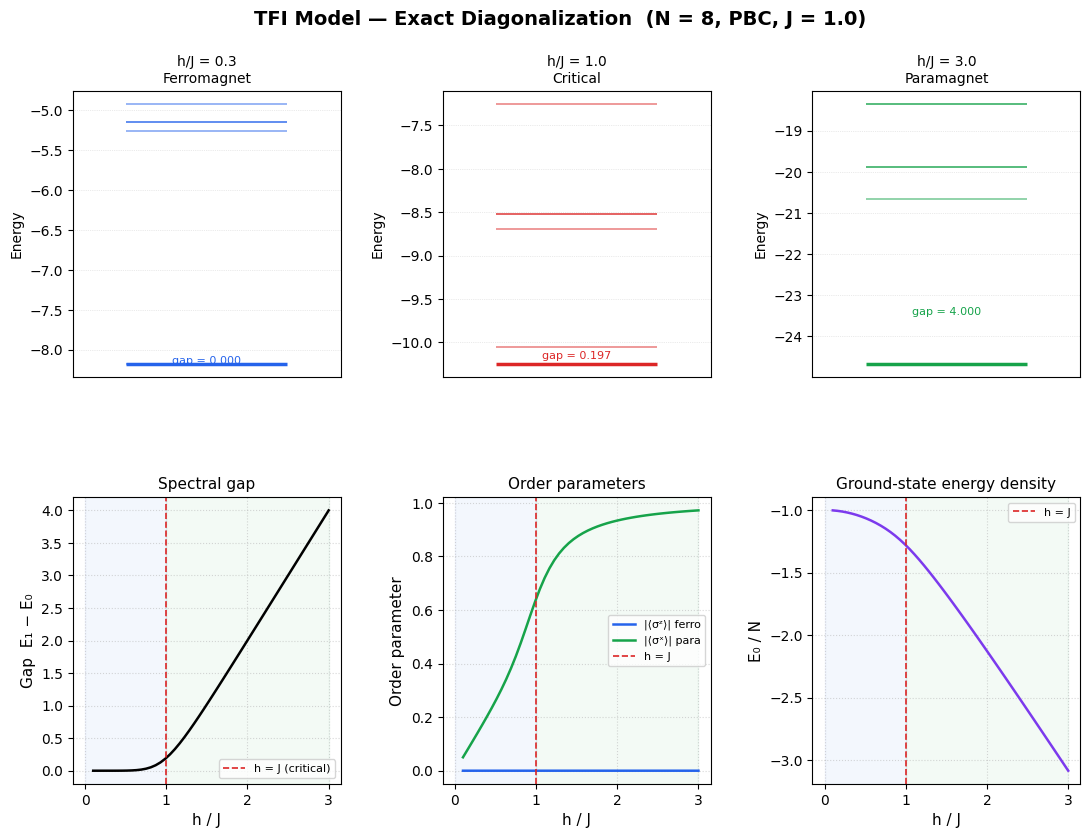

In [11]:
demo(N=8)

At the critical point h = J, the energy gap between the ground state and the first excited state closes in the thermodynamic limit $N \rightarrow \infty $. 
Let's investigate this!

  TFI Exact Diagonalization — Critical Regime (h = J = 1.0), PBC
N =  4 | Gap (E1 - E0) = 0.397825
N =  6 | Gap (E1 - E0) = 0.263305
N =  8 | Gap (E1 - E0) = 0.196983
N = 10 | Gap (E1 - E0) = 0.157403
N = 12 | Gap (E1 - E0) = 0.131087
N = 14 | Gap (E1 - E0) = 0.112318


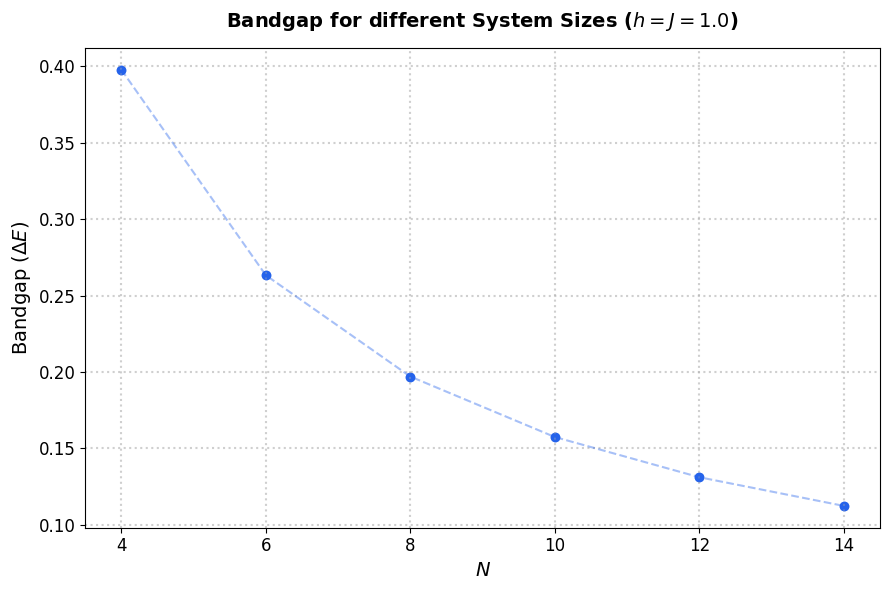

In [12]:
def scan_critical_N(N_values: list[int] = [4, 6, 8, 10, 12, 14]):
    """
    Investigates the critical regime (h = J) of the TFI model
    across different system sizes N, plotting the bandgap vs N.
    """
    J = 1.0
    h = 1.0  
    
    print("=" * 62) 
    print(f"  TFI Exact Diagonalization — Critical Regime (h = J = {J}), PBC")
    print("=" * 62)

    gaps = []
    
    # ── Calculate gap for each N ─────────────────────────────────────────────
    for N in N_values:
        #solve for values of N and store the gap
        energies, states, gap = solve_tfi(N, J, h, pbc=True, n_states=4)
        gaps.append(gap)
        
        print(f"N = {N:2d} | Gap (E1 - E0) = {gap:.6f}")

    # ── Plotting ─────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 6))
    
    # Plot gap vs N
    ax.scatter(N_values, gaps, marker='o', color='#2563eb')
    ax.plot(N_values, gaps, marker='o', linestyle='dashed', color='#2563eb', linewidth=1.5, alpha=0.4)

    # Formatting
    ax.set_title(r"Bandgap for different System Sizes ($h = J = 1.0$)", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(r"$N$", fontsize=14)
    ax.set_ylabel(r"Bandgap ($\Delta E$)", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    
    ax.set_xticks(N_values) 
    ax.grid(linestyle=':', linewidth=1.5, alpha=0.6)
    
    plt.tight_layout()
    plt.show()

scan_critical_N([4, 6, 8, 10, 12, 14])

## Problem 1.2 FFNN which produces a complex NQS (log-amplitude + phase)

We'll create a small feed-forward neural network that given a spin configuration
(array of +1/-1 or 0/1) outputs two real numbers: `log_amp` and `phase`.
The wavefunction for configuration `s` is then
$ \psi(s) = \exp( \mathrm{log\_amp}(s) + i \cdot \mathrm{phase}(s) ) $.

Set up a FFNN. Try to figure out input/output dimensions. For small chain L=6 this is easy to test. **Some lines are intentionally left incomplete for you to fill.** 


In [13]:
# Reproducibility
np.random.seed(0)
torch.manual_seed(0)

In [14]:
# Simple FFNN
class ComplexNQS(nn.Module):
    def __init__(self, n_spins, hidden=64):
        super().__init__()
        
        # TODO set up a FFNN network
        self.net = nn.Sequential(
            nn.Linear(n_spins, hidden), 
            nn.ReLU(),
            #we can also add more layers if we want
            #nn.Linear(hidden, hidden),
            #nn.ReLU(),
            nn.Linear(hidden, 2)  # Output: log amplitude and phase
        )

    def forward(self, x):
        # TODO pass x through the network
        out = self.net.forward(x)
        log_amp = out[:, 0]  # log amplitude
        phase = out[:, 1]    # phase
        return log_amp, phase

    def psi(self, x):
        log_amp, phase = self.forward(x)
        amp = torch.exp(log_amp)
        return amp * torch.cos(phase) + 1j * amp * torch.sin(phase)


In [15]:
# Quick test
L = 6
model = ComplexNQS(L, hidden=32)
# random config in +/-1
x = torch.tensor(np.random.choice([-1.0, 1.0], size=(1, L)), dtype=torch.float32) #specific random configuration of spins

la, ph = model(x)  #forward pass through the network to get log amplitude and phase

In [16]:
# they change for every run since the network is randomly initialized
print("Log amplitude:", la.item())
print("Phase:", ph.item())

Log amplitude: 0.021325819194316864
Phase: 0.09595729410648346


## Quick training sanity check
To give immediate meaning on day 1, train the network to approximate a
*known* target wavefunction: the product state $|+++...+ \rangle $ in the X-basis.
Its amplitude in the Z-basis ($ |0/1 \rangle$ as eigenstates of Sz is:
$ \psi(s) = (1/\sqrt{2})^L \prod_i 1 $ up to a global constant, i.e. same
amplitude for all configurations with zero phase. This is a good toy task:
the network should learn constant log_amp and zero phase.


### Short PyTorch gradient reminder

The next cell uses PyTorch's automatic differentiation engine, `autograd`. During the forward pass, PyTorch records all tensor operations that depend on trainable parameters. Calling

```python
loss.backward()
```

then traverses this computation graph backwards and stores the derivatives $\partial \mathrm{loss}/\partial \theta_k$ in the `.grad` attribute of every trainable parameter. Since gradients are **accumulated** by default, one usually calls

```python
optimizer.zero_grad()
```

before each new backward pass. Finally,

```python
optimizer.step()
```

updates the parameters using the gradients currently stored in `.grad`.

Later, for VMC, we need derivatives of the wavefunction itself rather than of an ordinary supervised-learning loss. The relevant object is the logarithmic derivative

$$
O_k(\sigma) = \partial_{\theta_k} \log \Psi_\theta(\sigma).
$$

In our parametrization, the network outputs a log-amplitude and a phase,

$$
\log \Psi_\theta(\sigma) = \log |\Psi_\theta(\sigma)| + i\,\phi_\theta(\sigma),
$$

so we can obtain $O_k$ by separately backpropagating through the log-amplitude and through the phase, then combining the two gradients as

$$
O_k = \partial_{\theta_k}\log |\Psi_\theta| + i\,\partial_{\theta_k}\phi_\theta.
$$

For reference, see the official PyTorch autograd tutorial: https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html

In [17]:
# prepare dataset: all configurations in {-1,1}^L
def all_configs(L):
    configs = np.array(list(itertools.product([-1, 1], repeat=L)), dtype=np.float32)
    return configs

configs = all_configs(L)
configs_t = torch.tensor(configs)

# target: constant log_amp and zero phase
target_log_amp = -0.5 * L * np.log(2.0)  # unimportant constant

opt_model = ComplexNQS(L, hidden=64)               #initialize a new model that we will optimize to learn the target state
opt = optim.Adam(opt_model.parameters(), lr=1e-2)  #ADAM optimizer

for epoch in range(1000):
    opt.zero_grad()
    la, ph = opt_model(configs_t)
    # MSE to constant: try to learn log_amp==target and phase==0
    loss = ((la - target_log_amp) ** 2).mean() + (ph ** 2).mean()
    loss.backward()
    opt.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch:3d} loss {loss.item():.4e}')

print('Target log_amp', target_log_amp.item())
print('Learned mean log_amp', la.mean().item(), 'mean phase', ph.mean().item())

Epoch   0 loss 4.7998e+00
Epoch  50 loss 1.1451e-02
Epoch 100 loss 7.8065e-04
Epoch 150 loss 2.5644e-04
Epoch 200 loss 9.6970e-05
Epoch 250 loss 3.9151e-05
Epoch 300 loss 1.7035e-05
Epoch 350 loss 8.0388e-06
Epoch 400 loss 4.1573e-06
Epoch 450 loss 2.3361e-06
Epoch 500 loss 1.3946e-06
Epoch 550 loss 8.6568e-07
Epoch 600 loss 5.6666e-07
Epoch 650 loss 3.7668e-07
Epoch 700 loss 2.5011e-07
Epoch 750 loss 1.6423e-07
Epoch 800 loss 1.0833e-07
Epoch 850 loss 7.1704e-08
Epoch 900 loss 4.7202e-08
Epoch 950 loss 3.0724e-08
Target log_amp -2.0794415416798357
Learned mean log_amp -2.079441547393799 mean phase 8.742790669202805e-08


## Problem 1.3 Metropolis sampling 
We'll implement a Metropolis sampler in the computational basis using single
spin flips. **Some lines are intentionally left incomplete for you to fill.** 

In [18]:
def metropolis_sampler(model, n_samples, n_burn=190, L=6, x0=None):
    """
    Metropolis sampling of spin configurations using single-spin flips.

    model: ComplexNQS instance
    n_samples: number of *accepted* samples to return
    n_burn: number of initial proposals to discard
    L: number of spins
    x0: initial configuration (1D array) or None

    Returns: samples (n_samples, L), acceptance_ratio

    """
    if x0 is None:
        cur = np.random.choice([-1, 1], size=(L,)).astype(np.float32)
    else:
        cur = x0.copy().astype(np.float32)

    samples = []
    n_accept = 0
    n_total = 0

    # compute log|psi| for current config
    with torch.no_grad():
        cur_t = torch.tensor(cur.reshape(1, -1))
        la_cur, ph_cur = model(cur_t)
        logpsi_cur = la_cur.item()  # we only need log amplitude for Metropolis

    # burn-in
    #here in the burn-in phase we do not record samples, we just want to reach a typical configuration
    #we almost do the same as in the sampling phase, but we do not record samples and we do not count acceptance ratio

    for _ in range(n_burn):
        # propose update
        # TODO: write a proposed update of the config (e.g. a spin flip)
        prop = cur.copy()
        flip_idx = np.random.randint(0, L)
        prop[flip_idx] *= -1  # flip one random spin

        # TODO: compute logpsi for proposed config
        with torch.no_grad():
            prop_t = torch.tensor(prop.reshape(1, -1))
            la_prop, ph_prop = model(prop_t)
            logpsi_prop = la_prop.item()
                
        # TODO: fill acceptance rule using metropolis-Hastings for symmetric proposal
        acc = min(1.0, np.exp(2.0 * (logpsi_prop - logpsi_cur))) 
        
        if np.random.rand() < acc:
            cur = prop
            logpsi_cur = logpsi_prop
        
    # sampling
    while len(samples) < n_samples:
        i = np.random.randint(0, L)
        prop = cur.copy()
        prop[i] *= -1

        with torch.no_grad():
            prop_t = torch.tensor(prop.reshape(1, -1))
            la_prop, ph_prop = model(prop_t)
            logpsi_prop = la_prop.item()

        #acceptance rule
        acc = min(1.0, np.exp(2.0 * (logpsi_prop - logpsi_cur)))
        # record
        if np.random.rand() < acc:
            cur = prop
            logpsi_cur = logpsi_prop
            n_accept += 1
        n_total += 1
        samples.append(cur.copy())

    samples = np.array(samples, dtype=np.float32)
    return samples, n_accept / max(1, n_total)

    

# quick test
samps, acc = metropolis_sampler(opt_model, n_samples=100, n_burn=10, L=L)
print('Samples shape:', samps.shape, 'acceptance ratio:', acc)


Samples shape: (100, 6) acceptance ratio: 1.0



## Problem 1.4 Sampling an observable


#### Analytically

If we want to be consistent to what is written in the PDF. 
The expectation value of a general quantum mechanical observable $\hat O$ for our trial wavefunction $\ket {\psi_\theta}$ is
given by:
\begin{equation}
 \braket {\hat{O}}_{\theta} = \frac{\braket{ \psi_{\theta} |\hat{O} |\psi_{\theta} }}{ \braket{\psi_{\theta}|\psi_{\theta}}} 
\end{equation}

We know that the identity operator over our chosen computational basis is: 
$$ I = \sum_\sigma \ket{\sigma}\bra{\sigma} $$

With the help of I we can express:

$$\braket{\psi_\theta |\psi_\theta } = \sum_\sigma \braket{\psi_\theta|\sigma}\braket{\sigma|\psi_\theta} = \sum_\sigma |\psi_\theta (\sigma)|^2 $$

The numerator:

\begin{align*}
\braket{ \psi_{\theta} |\hat{O} |\psi_{\theta} } &= \sum_\sigma \sum_{\sigma'} \braket{\psi_\theta|\sigma} \braket {\sigma | \hat{O} |\sigma'} \braket{\sigma' |\psi_\theta} \\ &= \sum_{\sigma}\sum_{\sigma'} \psi^*_{\theta}(\sigma)\braket{\sigma|\hat{O}|\sigma'}\psi_\theta(\sigma') \\ &=   \sum_{\sigma}\sum_{\sigma'} \psi^*_{\theta}(\sigma)\psi_{\theta}(\sigma) \frac{\braket{\sigma|\hat{O}|\sigma'} \psi_\theta(\sigma') }{\psi_\theta(\sigma)} \\ &= \sum_{\sigma}\sum_{\sigma'} |\psi_{\theta}(\sigma)|^2 \left (\braket{\sigma|\hat{O}|\sigma'}\frac{\psi_\theta(\sigma') }{\psi_\theta(\sigma)}\right) \\ &= \sum_{\sigma} |\psi_{\theta}(\sigma)|^2 \left ( \sum_{\sigma'}\braket{\sigma|\hat{O}|\sigma'}\frac{\psi_\theta(\sigma') }{\psi_\theta(\sigma)}\right) \\& = \sum_\sigma |\psi_{\theta}(\sigma)|^2 O_{loc}(\sigma)
\end{align*}

So equation (1) becomes:

$$\braket{\hat{O}}_{\theta} = \frac{\sum_\sigma |\psi_\theta(\sigma)|^2 O_{loc }(\sigma)}{\sum_{\sigma'}|\psi_{\theta}(\sigma')|^2} $$

According to the Born rule: $$p_\theta(\sigma) = \frac{|\psi_{\theta}(\sigma)|^2}{\sum_{\sigma'}|\psi_{\theta}(\sigma')|^2}$$ 

So: 
$$\braket{\hat{O}}_{\theta} = p_\theta(\sigma) O_{loc}(\sigma) $$

### Rewriting so it matches the notebook's notation: 
Eq.(7):  $$ \braket{\psi |O| \psi} = \sum_{s,s'} \psi^*(s) O_{s,s'} \psi(s') $$

Eq.(8):  $$\braket{O} = \sum_s p(s) \sum_{s'} O_{s,s'} \frac{\psi(s')}{\psi(s)} $$ 
          where $p(s) = |\psi(s)|^2 / \mathcal{N}$

The goal is to how that Eq. (8) indeed calculates the same quantity as Eq. (7). 

#### Conversion to spin representation

In [19]:
# Represent basis states as integers 0 ... 2^L-1 for exact diagonalization
#We need to convert between integer representation of basis states (0,1,2,...,2^L-1) and spin vector representation (-1,+1) for the network input. 

def int_to_spinvec(x, L):
    # return +/-1 array
    bits = np.array([(x >> i) & 1 for i in range(L)], dtype=np.int8)
    return 2 * bits - 1

def spinvec_to_int(s):
    # s is +/-1
    bits = ((s == 1).astype(int)).astype(int)
    out = 0
    for i, b in enumerate(bits):
        out |= (b << i)
    return out

#### Numerically: 
The goal is to how that Eq. (8) indeed calculates the same quantity as Eq. (7). 

In [20]:
# ── 1.   Full wavefunction vector over all 2^L basis states ─────────────────────────

all_cfgs = np.array(list(itertools.product([-1,1], repeat=L)), dtype=np.float32)
# state ordering: all_cfgs[i] corresponds to integer i (via spinvec_to_int)

with torch.no_grad():
    psi_vec = model.psi(torch.tensor(all_cfgs)).numpy()   # shape (2^L,)

norm2 = (np.abs(psi_vec)**2).sum()
p_vec = np.abs(psi_vec)**2 / norm2                        # normalised probabilities

dim = 2**L
print(f"Hilbert-space dim = {dim},  ‖ψ‖² = {norm2:.4f}")

# ── 2.  Build two test operators ─────────────────────────────────────────────

# (a) SPARSE: total transverse magnetisation  Σ_i σ^x_i
#     Each row has exactly L non-zero entries (one per spin flip).
def build_sigmax_total(L):
    dim = 2**L
    rows, cols, data = [], [], []
   # TODO: write sparse observable
    for state in range(dim): 
        for i in range(L):
            flipped = state ^ (1 << i)  # flip bit i
            rows.append(state)
            cols.append(flipped)    
            data.append(1.0 / L)    # normalise by L since we want the average magnetisation per spin
    return sparse.coo_matrix((data, (rows, cols)), shape=(dim, dim)).tocsr()

O_sparse = build_sigmax_total(L)

# (b) DENSE: random Hermitian matrix — every row is fully coupled.
rng    = np.random.default_rng(42)
A      = rng.standard_normal((dim, dim)) + 1j * rng.standard_normal((dim, dim))
O_dense = (A + A.conj().T) / 2.0          # Hermitian

# ── 3.  Eq.(7): direct matrix element ⟨ψ|O|ψ⟩ / ⟨ψ|ψ⟩ ─────────────────────
def expectation_eq7(psi, O, is_sparse=False):
    psi_n = psi / np.sqrt((np.abs(psi)**2).sum())       # normalise wavefunction
    Opsi  = O.dot(psi_n) if is_sparse else O @ psi_n    # apply operator to wavefunction
    return (psi_n.conj() @ Opsi).real                   # expectation value (real part)

# ── 4.  Eq.(8): exact weighted sum (no Monte Carlo noise yet) ────────────────
def expectation_eq8_exact(psi_vec, p_vec, O, is_sparse=False):
    """Exact Eq.(8): iterates over all basis states (feasible for small L)."""
    # TODO: write a function that evaluates Eq.(8) for the observable

    # Apply the operator to the wavefunction (numerator of Eq. 10 in the PDF)
    # This computes sum_{sigma'} <sigma|O|sigma'> Psi(sigma')
    Opsi = O.dot(psi_vec) if is_sparse else O @ psi_vec
    
    # Compute the local observable O_loc(sigma) for all states (Eq. 10 in the PDF)
    # O_loc(sigma) = Opsi(sigma) / Psi(sigma)
    O_loc = np.zeros_like(psi_vec, dtype=np.complex128)
    O_loc = Opsi / psi_vec
    
    # Compute the expectation value over the classical distribution 
    # sum_{sigma} p(sigma) * O_loc(sigma)
    expectation_value = np.sum(p_vec * O_loc)
    
    return expectation_value.real

# ── 5.  Compare Eq.(7) vs Eq.(8) ─────────────────────────────────────────────
print("\n  Verifying Eq.(7) == Eq.(8)\n" + "─"*50)
for label, O, sp in [("SPARSE  Σ σˣᵢ      ", O_sparse, True),
                     ("DENSE   random Herm.", O_dense,  False)]:
    e7 = expectation_eq7(psi_vec, O, sp)
    e8 = expectation_eq8_exact(psi_vec, p_vec, O, sp)
    print(f"  {label}  Eq.(7)={e7:+.8f}  Eq.(8)={e8:+.8f}  |diff|={abs(e7-e8):.2e}")

Hilbert-space dim = 64,  ‖ψ‖² = 58.6540

  Verifying Eq.(7) == Eq.(8)
──────────────────────────────────────────────────
  SPARSE  Σ σˣᵢ        Eq.(7)=+0.96813393  Eq.(8)=+0.96813399  |diff|=6.64e-08
  DENSE   random Herm.  Eq.(7)=-0.97167329  Eq.(8)=-0.97167339  |diff|=1.04e-07


Explain why this can only be efficiently evaluated if the matrix corresponding to the observable $\hat{O}$ is sparse.  

The evaluation of Eq.(8) involves computing the local observable $O_{loc}(\sigma)$ for each basis state sigma, which requires applying the operator O to the wavefunction $\ket{\psi}$. If $O$ is dense, applying it to $\ket{\psi}$ would require $O(\mathrm{dim}^2)$ operations, where dim $= 2^L$ is the size of the Hilbert space. This becomes very for large $L$ due to the exponential growth of dim. However, if $O$ is sparse (e.g., has only $O(L)$ non-zero entries per row), then applying $O$ to $\ket{\psi}$ can be done in $O(L \cdot \mathrm{dim})$. Therefore, efficient evaluation of Eq.(8) relies on the sparsity of the operator O. 

In [21]:
# ── 6.  Monte Carlo estimator via Metropolis (sparse operator only) ──────────
# In practice we do NOT loop over all s; we sample s ~ p(s) and average O_loc.
N_MC      = 2000
samps, _  = metropolis_sampler(model, n_samples=N_MC, n_burn=200, L=L)

mc_vals = []
# TODO: evaluate Eq.(8) through sampling using your metropolis sampler 
# and evaluate mean and std for the local 
# estimator O_loc(s) = ⟨s|O|ψ⟩ / ψ(s) for each sampled s.
for s in samps:
    s_int = spinvec_to_int(s)
    O_loc = O_sparse[s_int].dot(psi_vec) / psi_vec[s_int]  # local estimator for this sampled config
    mc_vals.append(O_loc)

E_mc  = np.mean(mc_vals)
E_std = np.std(mc_vals) / np.sqrt(N_MC)
e7_sp = expectation_eq7(psi_vec, O_sparse, True)

print(f"\n  MC Eq.(8) estimator  (N={N_MC} Metropolis samples)")
print(f"    MC  ⟨O⟩  = {E_mc:.6f} ± {E_std:.4f}")
print(f"    Exact    = {e7_sp:.6f}")
print(f"    Error    = {abs(E_mc - e7_sp):.4f}   (1/√N ≈ {1/N_MC**0.5:.4f})")



  MC Eq.(8) estimator  (N=2000 Metropolis samples)
    MC  ⟨O⟩  = 0.988120+0.001437j ± 0.0026
    Exact    = 0.968134
    Error    = 0.0200   (1/√N ≈ 0.0224)


### Comment on the output

Why is this not the correct expectation value?  
The MC is an unbiased estimator of the expectation value, but it has statistical noise due to the finite number of samples. The error should decrease as $1/\sqrt{N_{MC}}$, but for small $N_{MC}$ the estimate can deviate significantly from the exact value. Additionally, if the wavefunction has very small amplitudes for certain configurations, the local estimator $O_{loc}(s)$ can have large variance, which also contributes to the error in the MC estimate.

### Error vs Monte Carlo sample sizes

In [22]:
# Define a range of sample sizes from 100 to 100000 on a logarithmic scale
N_vals = np.logspace(2, 5, num=15, dtype=int) 
errors = []
std_devs = []

print(f"\nRunning Monte Carlo scaling test...")
print(f"{'N_MC':>8} | {'MC ⟨O⟩':>10} | {'Error':>10} | {'Std Dev':>10}")
print("-" * 47)

for N_MC in N_vals:
    # Run the Metropolis sampler for the current N_MC
    samps, _ = metropolis_sampler(model, n_samples=N_MC, n_burn=200, L=L)
    
    mc_vals = []
    for s in samps:
        s_int = spinvec_to_int(s)
        # Local estimator for this sampled config
        O_loc = O_sparse[s_int].dot(psi_vec) / psi_vec[s_int]  
        mc_vals.append(O_loc.real) # Assuming O_loc is real for this observable
        
    E_mc = np.mean(mc_vals)
    E_std = np.std(mc_vals) / np.sqrt(N_MC)
    
    error = abs(E_mc - e7_sp)
    
    errors.append(error)
    std_devs.append(E_std)
    
    print(f"{N_MC:8d} | {E_mc:10.6f} | {error:10.6f} | {E_std:10.6f}")


Running Monte Carlo scaling test...
    N_MC |     MC ⟨O⟩ |      Error |    Std Dev
-----------------------------------------------
     100 |   0.972445 |   0.004311 |   0.007435
     163 |   0.988834 |   0.020700 |   0.005560
     268 |   0.995271 |   0.027137 |   0.004447
     439 |   0.996155 |   0.028021 |   0.003584
     719 |   0.984698 |   0.016564 |   0.002837
    1178 |   0.994398 |   0.026264 |   0.002215
    1930 |   0.984182 |   0.016048 |   0.001709
    3162 |   0.985706 |   0.017572 |   0.001291
    5179 |   0.987342 |   0.019208 |   0.001009
    8483 |   0.990651 |   0.022517 |   0.000817
   13894 |   0.988240 |   0.020106 |   0.000630
   22758 |   0.990127 |   0.021993 |   0.000493
   37275 |   0.989798 |   0.021664 |   0.000386
   61054 |   0.989544 |   0.021410 |   0.000301
  100000 |   0.990294 |   0.022160 |   0.000235


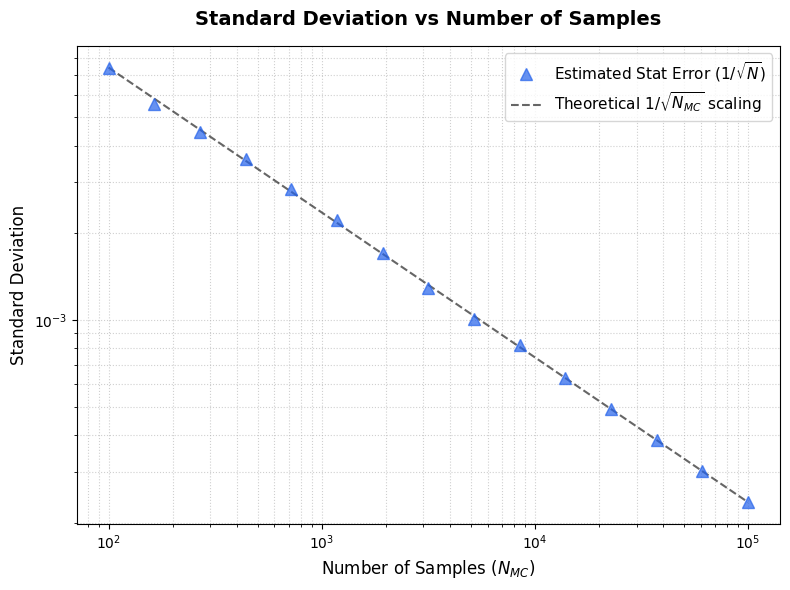

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot standard statistical error (standard deviation of the mean)
ax.loglog(N_vals, std_devs, marker='^', linestyle='', color='#2563eb', 
          label=r'Estimated Stat Error ($1/\sqrt{N}$)', markersize=8, alpha=0.7, zorder=3)

# Add a theoretical reference line (1/sqrt(N) slope)
# We scale it to match the first error point so they start at a similar height
ref_line = std_devs[0] * np.sqrt(N_vals[0] / N_vals)
ax.loglog(N_vals, ref_line, linestyle='--', color='black', alpha=0.6, zorder=2, label=r'Theoretical $1/\sqrt{N_{MC}}$ scaling')

ax.set_title(r"Standard Deviation vs Number of Samples", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel(r"Number of Samples ($N_{MC}$)", fontsize=12)
ax.set_ylabel(r"Standard Deviation", fontsize=12)
ax.grid(True, which="both", ls=":", alpha=0.6)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

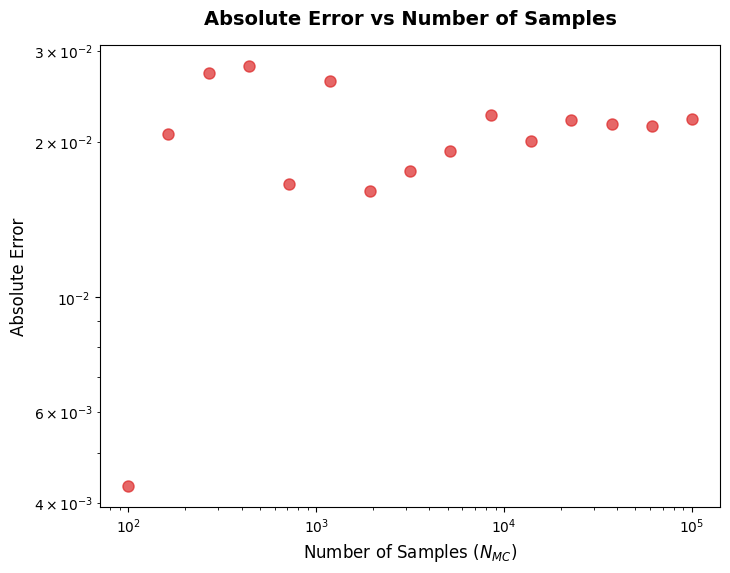

In [24]:
plt.figure(figsize=(8, 6))
plt.loglog(N_vals, errors, marker='o', linestyle='', color='#dc2626', label='Actual Error', markersize=8, alpha=0.7)
plt.title(r"Absolute Error vs Number of Samples", fontsize=14, fontweight='bold', pad=15)
plt.xlabel(r"Number of Samples ($N_{MC}$)", fontsize=12)
plt.ylabel(r"Absolute Error", fontsize=12)
plt.show()

## Problem 1.5 Connected elements & local energy

The local energy is the key VMC quantity:

$$E_{\mathrm{loc}}(\sigma) = \sum_{\sigma'} H_{\sigma\sigma'} \frac{\Psi_\theta(\sigma')}{\Psi_\theta(\sigma)}$$

For TFI only $L+1$ configurations $\sigma'$ contribute: 1 diagonal ($-J\sum_i \sigma^z_i\sigma^z_{i+1}$) and $L$ off-diagonal ($-h\sigma^x_i$ flips spin $i$).

The gradient uses the log-derivative trick (Eq. 16):

$$\nabla_{\theta_k} E_\theta = 2\,\mathrm{Re}\!\left[\langle E_{\mathrm{loc}}\,O_k^*\rangle - \langle E_{\mathrm{loc}}\rangle\langle O_k^*\rangle\right]$$

In [25]:
# Problem 1.5: connected elements & batched local energy

# The local energy needs all non-zero matrix elements H_{s,s'} connected to a sample s.
# For the TFIM these are especially simple:
#   - one diagonal contribution from the Ising term
#   - L off-diagonal contributions from flipping one spin with sigma^x_i


def connected_elements_tfim(s_int, L, J=1.0, h=1.0, pbc=True):
    """
    Return connected basis states and matrix elements H_{s,s'} for

        H = -J sum_i sz_i sz_{i+1} - h sum_i sx_i.

    Returns
    -------
    s_primes : list[int]
        Basis states s' for which H_{s,s'} is non-zero.
    mels : list[float]
        Corresponding matrix elements H_{s,s'}.
    """

    # Hint 1: convert the integer basis label into a spin vector (+/-1)
    s = int_to_spinvec(s_int, L) #use the function we build earlier 
    
    s_primes = []               #to store the connected states s' (as integers)
    mels = []                   #to store the connected states and their matrix elements

    # Hint 2: add the diagonal Ising contribution.
    # It should connect s_int only to itself.
    # For PBC, include the bond (L-1, 0).
    diag = 0.0
    for i in range(L - 1):
        diag -= J * s[i] * s[i + 1] 
    if pbc:
        diag -= J * s[L - 1] * s[0]     #periodic boundary condition term

    s_primes.append(s_int)  # the diagonal term connects s to itself
    mels.append(diag)       # the corresponding matrix element is the diagonal energy contribution

    # Hint 3: add the transverse-field terms.
    # Each sigma^x_i flips one spin and gives matrix element -h.
    for i in range(L):
        s2 = s.copy()               # make a copy of the spin vector to flip so we don't modify the original s
        s2[i] *= -1                 # flip spin i
        s2_int = spinvec_to_int(s2) # convert back to integer basis representation
        s_primes.append(s2_int)     # add this connected state to the list
        mels.append(-h)             # each flip contributes -h to the matrix element

    return s_primes, mels


def local_energy_batch(model, samples_int, L, J=1.0, h=1.0, pbc=True):
    """
    Compute the local energy

        E_loc(s) = sum_{s'} H_{s,s'} psi(s') / psi(s)

    for a batch of integer-encoded samples.
    """

    # Suggested structure:
    # 1. For every sample s, call connected_elements_tfim(s, ...)
    
    all_needed = set() # to store all unique states s' that we need to evaluate psi(s') for
    conn_cache = {}    # to store the connected states and matrix elements for each sample s
    psi_cache = {}     # to store the computed psi values for the unique states

    with torch.no_grad():
        for s_int in samples_int:
            s_primes, mels = connected_elements_tfim(s_int, L, J, h, pbc)   # get connected states and matrix elements for this sample
            conn_cache[s_int] = (s_primes, mels)                            # cache this for later use when we compute E_loc                        
            all_needed.update(s_primes)                                     # add these connected states to the set of all needed states for psi evaluation 

    # 2. Collect all unique states whose psi value is needed
    all_needed = sorted(all_needed)  # sort for consistent ordering
    all_needed_vecs = np.array([int_to_spinvec(s, L) for s in all_needed], dtype=np.float32)

    # 3. Evaluate model.psi(...) once on this unique batch
    with torch.no_grad():
        all_needed_t = torch.tensor(all_needed_vecs)                  # convert to tensor for model input 
        psi_vals = model.psi(all_needed_t).numpy()                    # shape (num_unique_states,)
    
    # 4. Store the results in a dictionary {state_int: psi(state_int)}    
        psi_cache = {s: psi for s, psi in zip(all_needed, psi_vals)}  # map state_int to psi value
    state_to_psi = psi_cache 
    
    # 5. Assemble E_loc for every sample using the ratio psi(s') / psi(s)
    E_loc = np.zeros(len(samples_int), dtype=np.complex128)
    for i, s_int in enumerate(samples_int):
        s_primes, mels = conn_cache[s_int]
        psi_s = state_to_psi[s_int]  # psi(s)
        E_loc[i] = sum(mel * state_to_psi[s_prime] / psi_s for s_prime, mel in zip(s_primes, mels))
    
    return E_loc


# ── sanity check ─────────────────────────────────────────────
sp, me = connected_elements_tfim(0, L, J=1.0, h=1.0, pbc=True)                  #connected states and matrix elements for the all-up state (integer 0)
print(f'State 0: {len(sp)} connected states  (expected: 1 diag + {L} flips)')   #should be 1 diagonal term + L off-diagonal terms
if len(me) > 0:
    print(f'  diagonal mel = {me[0]:.2f}  (= -J*L for all spins aligned, PBC)')
    print(f'  off-diag mels = {set(me[1:])}')

test_ints = [np.random.randint(2**L) for _ in range(4)]
print('E_loc (4 random states):', local_energy_batch(model, test_ints, L).real.round(4))

State 0: 7 connected states  (expected: 1 diag + 6 flips)
  diagonal mel = -6.00  (= -J*L for all spins aligned, PBC)
  off-diag mels = {-1.0}
E_loc (4 random states): [-3.096  -7.8459 -8.028  -4.9358]


In [26]:
#Let's see the complete matrix element 
me

[np.float64(-6.0), -1.0, -1.0, -1.0, -1.0, -1.0, -1.0]

## Problem 1.6 + 1.7 Groundstate of TFI

In [27]:
# Problems 1.6 + 1.7: VMC gradient, training, benchmarking

# there were also TODO s here
def build_tfim_hamiltonian(L, h, J, pbc=True):
    """
    Build the sparse TFIM Hamiltonian using connected_elements_tfim.
    This is mainly needed for ED benchmarking in Problem 1.7.
    """
    # Suggested structure:
    rows, cols, data = [], [], []
    for s in range(2**L):
        s_primes, mels = connected_elements_tfim(s, L, J, h, pbc)   #get the connected states and matrix elements for each basis state s
        for s_prime, mel in zip(s_primes, mels):                    #for each connected state s' and its matrix element, we add an entry to the sparse matrix representation
            rows.append(s)
            cols.append(s_prime)
            data.append(mel)

    return sparse.coo_matrix((data, (rows, cols))).tocsr() #build the sparse Hamiltonian matrix in COO format and convert to CSR 

# there were also TODO s here
def groundstate_ED(L, h, J, pbc=True):
    """
    Compute the lowest ED eigenstates for comparison with VMC.
    """
    H = build_tfim_hamiltonian(L, h, J, pbc)          # we already have this function from before
    vals, vecs = spla.eigsh(H, k=2, which='SA')  # compute the two lowest eigenvalues/eigenvectors
    # sort eigenvalues/eigenvectors before returning
    idx = np.argsort(vals)
    vals = vals[idx]
    vecs = vecs[:, idx]

    return vals  


def _flatten_parameter_grads(params):
    """
    Helper: collect all parameter gradients into one flat vector.

    PyTorch stores gradients parameter by parameter in p.grad.
    For the VMC formula it is convenient to concatenate them into
    one vector indexed by k.
    """
    pieces = []
    for p in params:
        if p.grad is None:
            pieces.append(torch.zeros(p.numel(), dtype=p.dtype)) #if a parameter has no gradient we append a zero vector to maintain the correct shape
        else:
            pieces.append(p.grad.flatten())                      #flatten the gradient of this parameter and append to the list   
    return torch.cat(pieces).detach().clone()                    # concatenate all pieces into one flat vector and detach from the computation graph


def compute_O_k_batch(model, samples):
    """
    Compute logarithmic derivatives O_k(sigma) for a batch of samples.

    Since
        log psi = log_amp + i phase,
    we compute
        O_k = d log_amp / d theta_k + i d phase / d theta_k.

    Returns
    -------
    O_k : complex ndarray of shape (n_samples, n_parameters)
    """
    x = torch.tensor(samples, dtype=torch.float32)
    params = list(model.parameters())

    grad_logamp = []
    grad_phase = []

    for i in range(len(samples)):

        # Forward pass for one sample.
        # We use a batch dimension x[i:i+1] so the model input shape stays consistent.
        la, ph = model(x[i:i+1])

        # TODO: backpropagate through the log-amplitude la
        # Hint: clear old gradients first, then call backward.

        model.zero_grad()               #clear old gradients
        la.backward(retain_graph=True)  #backpropagate through log amplitude
        grad_logamp.append(_flatten_parameter_grads(params).numpy()) #store the gradients for log amplitude

        # TODO: backpropagate through the phase ph
        # Hint: this gives the imaginary part of O_k.
        model.zero_grad()               #clear old gradients again before backpropagating through phase
        ph.backward()   
        grad_phase.append(_flatten_parameter_grads(params).numpy())

    # TODO: combine real and imaginary parts
    return np.stack(grad_logamp) + 1j * np.stack(grad_phase)



def set_model_grad(model, flat_grad):
    """
    Copy a flat gradient vector back into the PyTorch model parameters.
    This allows us to use Adam with the manually estimated VMC gradient.
    """

    ptr = 0
    for p in model.parameters():
        n = p.numel()                                                               # get the number of elements in this parameter tensor                                           
        p.grad = torch.tensor(flat_grad[ptr:ptr+n].reshape(p.shape), dtype=p.dtype) # copy the corresponding slice of the flat gradient into p.grad
        ptr += n
    


def vmc_train(L, J, h, pbc=True, n_iter=100, n_samples=300,
              lr=5e-3, hidden=64, seed=0, verbose=True):
    """
    VMC optimization loop for the TFIM ground state.

    Each iteration should:
      1. sample configurations from |psi_theta|^2
      2. compute local energies E_loc(sigma)
      3. compute logarithmic derivatives O_k(sigma)
      4. estimate the energy gradient using Eq. (16)
      5. update the model parameters
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    nqs = ComplexNQS(L, hidden=hidden)
    opt = optim.Adam(nqs.parameters(), lr=lr)
    history = []

    for it in range(n_iter):

        # TODO: sample configurations
        samples, acc = metropolis_sampler(nqs, n_samples=n_samples, n_burn=200, L=L)  #we can reuse the metropolis_sampler function we wrote before to sample from |psi|^2

        # TODO: convert samples to integer basis labels
        samples_int = np.array([spinvec_to_int(s) for s in samples], dtype=np.int32) #we convert the sampled spin configurations into integer labels that correspond to the basis states for the local energy computation

        # TODO: compute local energy and mean energy
        E_loc = local_energy_batch(nqs, samples_int, L, J, h, pbc)  #compute the local energy for each sampled configuration
        E_mean = np.mean(E_loc)
        history.append(E_mean.real)  #store the mean energy in the history for plotting later

        # TODO: compute O_k and the VMC gradient
        O_k = compute_O_k_batch(nqs, samples) #compute the logarithmic derivatives O_k(sigma) for the sampled configurations
        # grad = 2 * Re[ <E_loc O_k^*> - <E_loc><O_k^*> ]
        grad = 2 * np.real(np.mean(E_loc[:, np.newaxis] * np.conj(O_k), axis=0) - E_mean * np.mean(np.conj(O_k), axis=0)) #compute the VMC gradient using the formula from the lecture notes

        # TODO: apply one optimizer step using the manually constructed gradient
        opt.zero_grad()           #clear old gradients in the optimizer
        set_model_grad(nqs, grad) #copy the manually computed gradient into the model parameters
        opt.step()                #perform an optimization step with Adam using the manually set gradients

        pass

    return nqs, np.array(history)

## Comparisons

### Convergence for 100 iterations


Training VMC for J = 1.00, h = 1.00
Final VMC energy: -7.626817, ED energy: -7.727407, Error: 0.1006


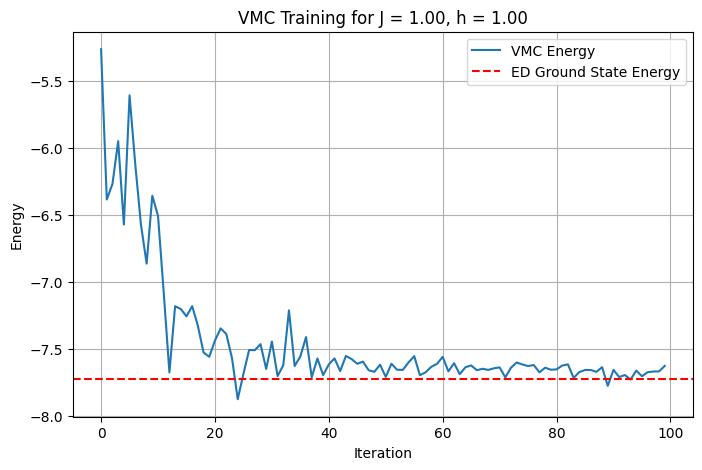


Training VMC for J = 0.30, h = 1.00
Final VMC energy: -6.135765, ED energy: -6.135950, Error: 0.0002


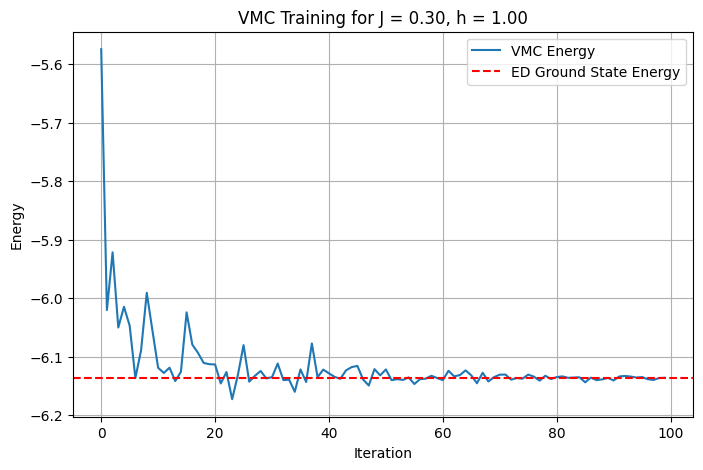


Training VMC for J = 3.00, h = 1.00
Final VMC energy: -18.207374, ED energy: -18.504540, Error: 0.2972


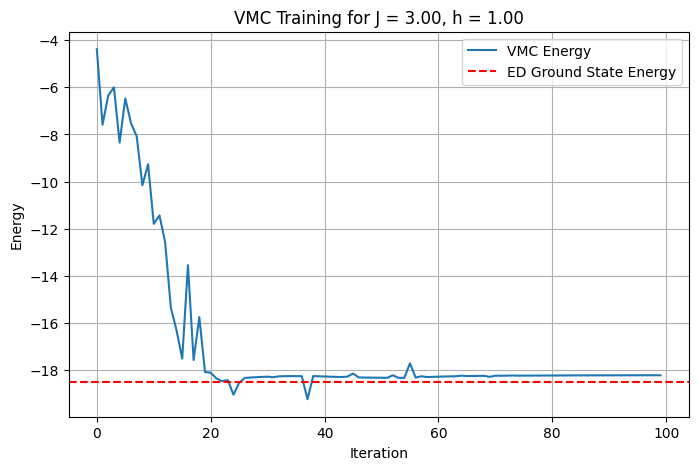

In [28]:
# Suggested benchmark workflow for Problem 1.7:
# - choose h < J, h = J, h > J
# - train one NQS for each regime
# - compare the final VMC energy to the ED ground-state energy
# - plot energy versus training iteration

L = 6

parameter_pairs = [
    (1.0, 1.0),
    (0.3, 1.0),
    (3.0, 1.0),
]

results = []

for J, h in parameter_pairs:

    print(f"\nTraining VMC for J = {J:.2f}, h = {h:.2f}")
    
    nqs, history = vmc_train(L,J,h, pbc=True, n_iter=100, n_samples=100, lr=1e-2, hidden=64, seed=42)
    E_vmc = history[-1]
    E_ed = groundstate_ED(L, h, J, pbc=True)[0]  # lowest ED energy
    results.append((J, h, E_vmc, E_ed))
    print(
        f"Final VMC energy: {E_vmc:.6f}, "
        f"ED energy: {E_ed:.6f}, "
        f"Error: {abs(E_vmc - E_ed):.4f}"
    )
    # Plot energy vs iteration
    plt.figure(figsize=(8, 5))
    plt.plot(history, label='VMC Energy')
    plt.axhline(E_ed, color='r', linestyle='--', label='ED Ground State Energy')
    plt.xlabel('Iteration')
    plt.ylabel('Energy')
    plt.title(f'VMC Training for J = {J:.2f}, h = {h:.2f}')
    plt.legend()
    plt.grid()
    plt.show()

### Convergence for 300 iterations


Training VMC for J = 1.00, h = 1.00
Final VMC energy: -7.722294, ED energy: -7.727407, Error: 0.0051


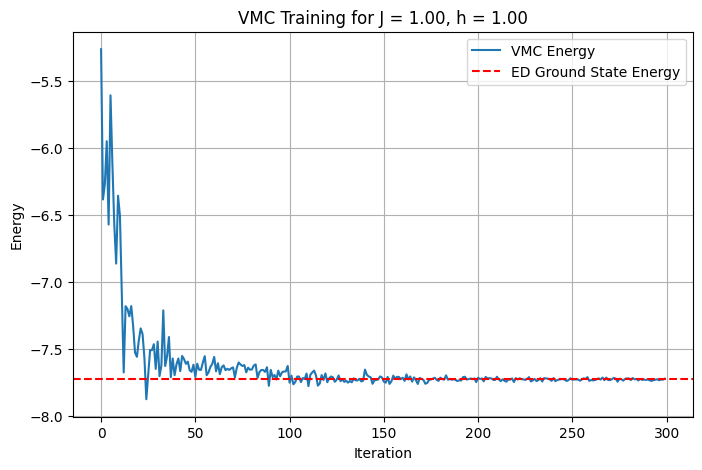


Training VMC for J = 0.30, h = 1.00
Final VMC energy: -6.135952, ED energy: -6.135950, Error: 0.0000


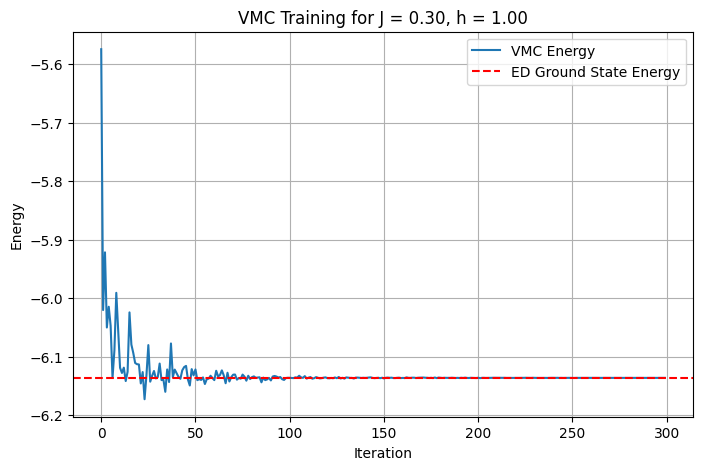


Training VMC for J = 3.00, h = 1.00
Final VMC energy: -18.397969, ED energy: -18.504540, Error: 0.1066


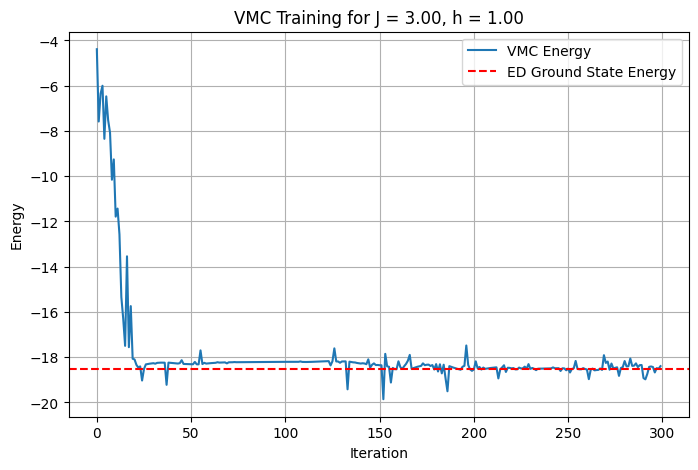

In [29]:
L = 6

parameter_pairs = [
    (1.0, 1.0),
    (0.3, 1.0),
    (3.0, 1.0),
]

results = []

for J, h in parameter_pairs:

    print(f"\nTraining VMC for J = {J:.2f}, h = {h:.2f}")
    
    nqs, history = vmc_train(L,J,h, pbc=True, n_iter=300, n_samples=100, lr=1e-2, hidden=64, seed=42)
    E_vmc = history[-1]
    E_ed = groundstate_ED(L, h, J, pbc=True)[0]  # lowest ED energy
    results.append((J, h, E_vmc, E_ed))
    print(
        f"Final VMC energy: {E_vmc:.6f}, "
        f"ED energy: {E_ed:.6f}, "
        f"Error: {abs(E_vmc - E_ed):.4f}"
    )
    # Plot energy vs iteration
    plt.figure(figsize=(8, 5))
    plt.plot(history, label='VMC Energy')
    plt.axhline(E_ed, color='r', linestyle='--', label='ED Ground State Energy')
    plt.xlabel('Iteration')
    plt.ylabel('Energy')
    plt.title(f'VMC Training for J = {J:.2f}, h = {h:.2f}')
    plt.legend()
    plt.grid()
    plt.show()

### Fixed training parameters, changing the number of samples

Training with n_samples = 10...
Training with n_samples = 50...
Training with n_samples = 500...
Training with n_samples = 1000...


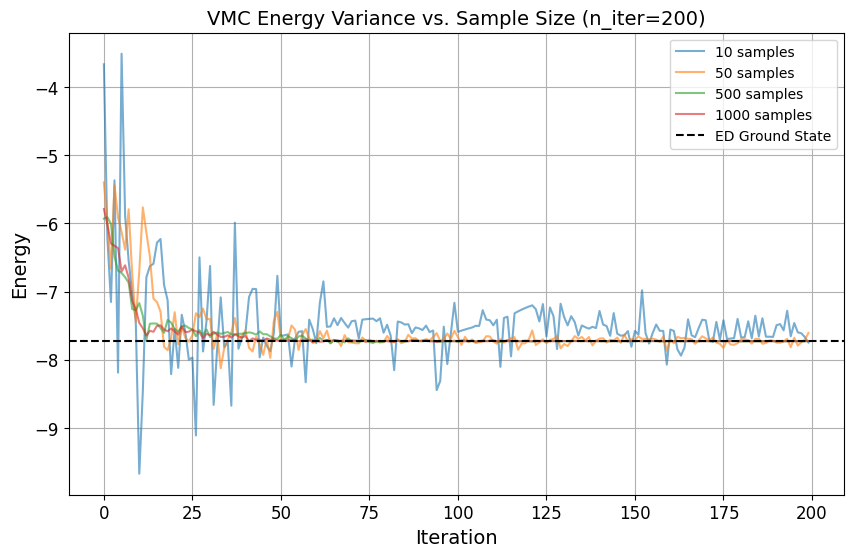

In [30]:
L = 6
J, h = 1.0, 1.0
E_ed = groundstate_ED(L, h, J, pbc=True)[0]

# Fixed training parameters, varying samples
sample_sizes = [10, 50, 500, 1000]

plt.figure(figsize=(10, 6))

for n_samples in sample_sizes:
    print(f"Training with n_samples = {n_samples}...")
    nqs, history = vmc_train(L, J, h, pbc=True, n_iter=200, n_samples=n_samples, lr=1e-2, hidden=64, seed=42)
    
    # Plot each history with a slight transparency to see overlapping lines
    plt.plot(history, label=f'{n_samples} samples', alpha=0.6)

plt.axhline(E_ed, color='k', linestyle='--', label='ED Ground State')
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('VMC Energy Variance vs. Sample Size (n_iter=200)', fontsize=14)
plt.tick_params(axis='both', labelsize=12)
plt.legend(fontsize=11)
plt.legend()
plt.grid()
plt.show()

### Varying network expressivity - changing the number of hidden layers

Training with hidden layer size = 2...
Training with hidden layer size = 8...
Training with hidden layer size = 64...
Training with hidden layer size = 128...


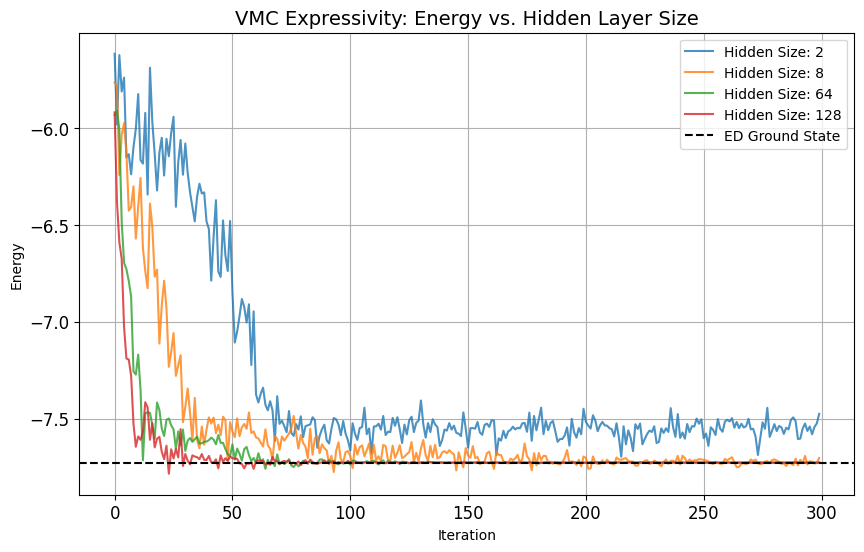

In [ ]:
L = 6
J, h = 1.0, 1.0
E_ed = groundstate_ED(L, h, J, pbc=True)[0]

# Varying network expressivity
hidden_sizes = [2, 8, 64, 128]

plt.figure(figsize=(10, 6))

for h_size in hidden_sizes:
    print(f"Training with hidden layer size = {h_size}...")
    
    # Notice we replace hidden=64 with hidden=h_size
    nqs, history = vmc_train(
        L, J, h, 
        pbc=True, 
        n_iter=300, 
        n_samples=500, 
        lr=1e-2, 
        hidden=h_size, 
        seed=42
    )
    
    plt.plot(history, label=f'Hidden Size: {h_size}', alpha=0.8)

plt.axhline(E_ed, color='k', linestyle='--', label='ED Ground State')
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('VMC Expressivity: Energy vs. Hidden Layer Size', fontsize=14)
plt.tick_params(axis='both', labelsize=12)
plt.legend(fontsize=11)
plt.legend()
plt.grid()
plt.show()

### Varying optimization stability - changing the learning rates

Training with learning rate = 0.1...
Training with learning rate = 0.01...
Training with learning rate = 0.001...


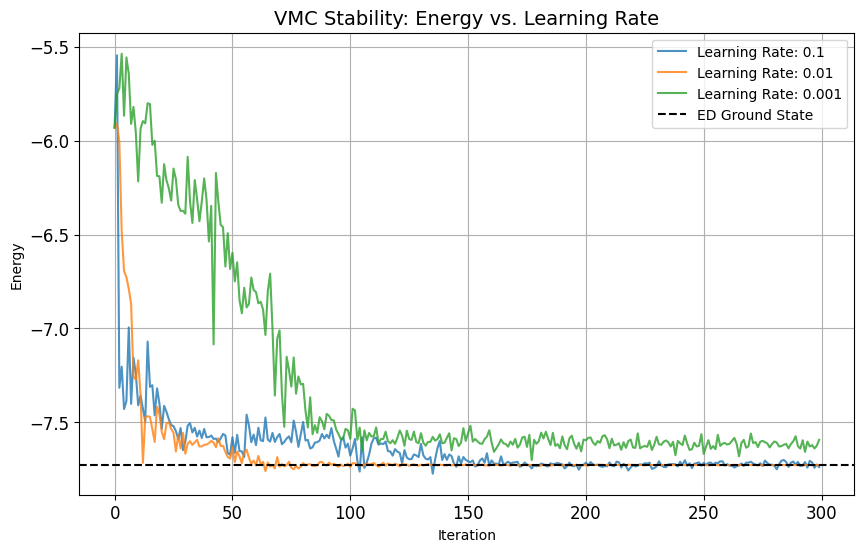

In [32]:
L = 6
J, h = 1.0, 1.0
E_ed = groundstate_ED(L, h, J, pbc=True)[0]

# Varying optimization stability
learning_rates = [0.1, 0.01, 0.001]

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    print(f"Training with learning rate = {lr}...")
    
    nqs, history = vmc_train(
        L, J, h, 
        pbc=True, 
        n_iter=300, 
        n_samples=500, 
        lr=lr, 
        hidden=64, 
        seed=42
    )
    
    plt.plot(history, label=f'Learning Rate: {lr}', alpha=0.8)

plt.axhline(E_ed, color='k', linestyle='--', label='ED Ground State')
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('VMC Stability: Energy vs. Learning Rate', fontsize=14)
plt.tick_params(axis='both', labelsize=12)
plt.legend(fontsize=11)
plt.legend()
plt.grid()
plt.show()

## Problem 1.8 Measurement of observables

In [33]:
# Problem 1.8: ground-state observables
# Suggested observables: <Sz>, <Sx>, <Sz_i Sz_j>


def estimate_observables_nqs(model, L, n_samples=2000):
    """
    Estimate observables from Monte Carlo samples of the optimized NQS.

    Diagonal observables can be averaged directly over samples.
    Off-diagonal observables require wavefunction ratios psi(s') / psi(s).
    """

    # TODO: draw samples from |psi|^2
    samples, acc = metropolis_sampler(model, n_samples=n_samples, n_burn=200, L=L)  #we can reuse the metropolis_sampler function to sample from |psi|^2

    # TODO: diagonal observable <Sz>
    sz = np.mean(samples)  # since samples are in {-1,1}, the mean gives us <Sz>

    # TODO: diagonal correlation <Sz_i Sz_j>
    # samples[:, :, np.newaxis] -> shape (n_samples, L, 1)
    # samples[:, np.newaxis, :] -> shape (n_samples, 1, L)
    # Resulting broadcast shape -> (n_samples, L, L)
    Czz = np.mean(samples[:, :, np.newaxis] * samples[:, np.newaxis, :], axis=0)

    # TODO: off-diagonal observable <Sx>
    # Hint: sigma^x_i connects s to the state with spin i flipped.
    # sx = average over samples of sum_i psi(s_flipped_i)/psi(s) / L
    sx = 0.0
    for s in samples:
        s_int = spinvec_to_int(s)
        for i in range(L):
            s_flipped = s.copy()
            s_flipped[i] *= -1  # flip spin i
            s_flipped_int = spinvec_to_int(s_flipped)
            with torch.no_grad():
                psi_s = model.psi(torch.tensor(s.reshape(1, -1), dtype=torch.float32)).item()
                psi_flipped = model.psi(torch.tensor(s_flipped.reshape(1, -1), dtype=torch.float32)).item()
                sx += psi_flipped / psi_s  # accumulate the ratio for this sample and flip
    sx /= (n_samples * L)  # average over samples and normalize by L
    return sz, Czz, sx


def estimate_observables_ed(gs_vec, L):
    """
    Compute the same observables exactly from the ED ground-state vector.
    """
    sz = 0.0
    Czz = np.zeros((L, L))
    sx = 0.0
    
    # TODO: loop over all basis states s
    # Diagonal observables are weighted by |psi(s)|^2.

    # Pre-calculate the total normalization factor
    norm = np.sum(np.abs(gs_vec)**2)

    for s_int in range(2**L):
        s = int_to_spinvec(s_int, L)
        psi_s = gs_vec[s_int]
        
        # Exact probability of being in state s
        p_s = np.abs(psi_s)**2 / norm


        # diagonal observable <Sz> and <Sz_i Sz_j> are weighted by p_s = |psi(s)|^2 / norm
        # get magnetization PER SITE,
        sz += p_s * np.mean(s)   
        Czz += p_s * np.outer(s, s) 

        # TODO: for <Sx>, connect each state to all one-spin-flipped states.
        # off-diagonal observable <Sx> is weighted by psi(s_flipped) / psi(s) for each flip, and then averaged over all flips and states    
        for i in range(L):
            s_flipped = s.copy()
            s_flipped[i] *= -1  # flip spin i
            s_flipped_int = spinvec_to_int(s_flipped)
            
            psi_flipped = gs_vec[s_flipped_int]
            
            # Accumulate the off-diagonal matrix element
            # <psi | Sx_i | psi> = sum_s psi*(s) * psi(s_flipped)
            sx += np.real(np.conj(psi_s) * psi_flipped) / norm

    # Average sx over the L sites to match the NQS code
    sx /= L

    return sz, Czz, sx

In [34]:
# Suggested comparison:
# for each trained NQS:
#   - estimate observables with Monte Carlo
#   - compute ED observables from the exact ground state
#   - compare numbers and, if useful, plot <Sz_i Sz_j>
#
# Note: For finite systems, the ED ground state preserves the global Z2 symmetry,
# so <Sz>_ED may vanish even in the ferromagnetic regime. The NQS can still
# spontaneously pick one symmetry-broken sector, so |<Sz>_NQS| is often the
# more meaningful quantity to compare.


Simulating Regime: Ferromagnetic (J > h) (J=3.0, h=1.0)
Training NQS...
Estimating NQS Observables...


/tmp/ipykernel_1189/1627920270.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # adjust layout to make room for colorbar


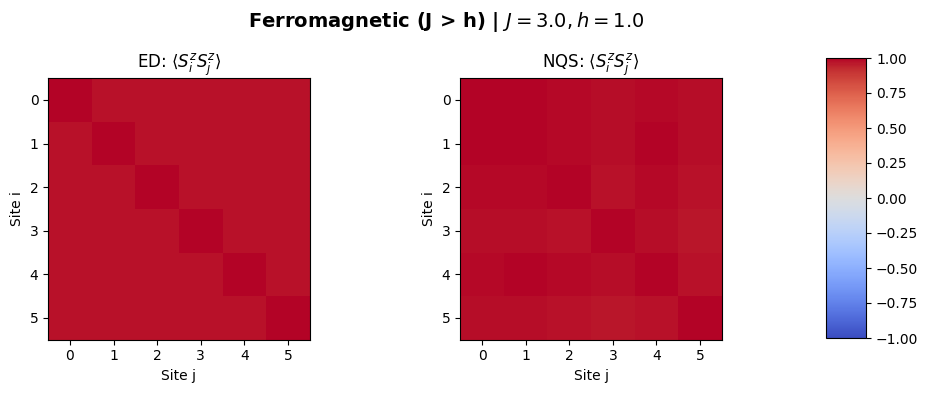

Magnetization <Sz> -> ED: 0.0000 | NQS: 0.9907
Transverse <Sx>    -> ED: 0.1700 | NQS: 0.1342

Simulating Regime: Paramagnetic (h > J) (J=0.3, h=1.0)
Training NQS...
Estimating NQS Observables...


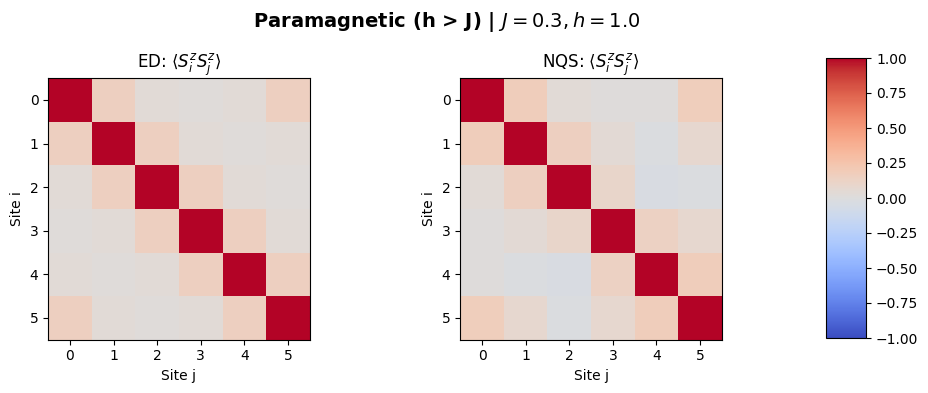

Magnetization <Sz> -> ED: 0.0000 | NQS: 0.0500
Transverse <Sx>    -> ED: 0.9770 | NQS: 0.9770

Simulating Regime: Critical (J = h) (J=1.0, h=1.0)
Training NQS...
Estimating NQS Observables...


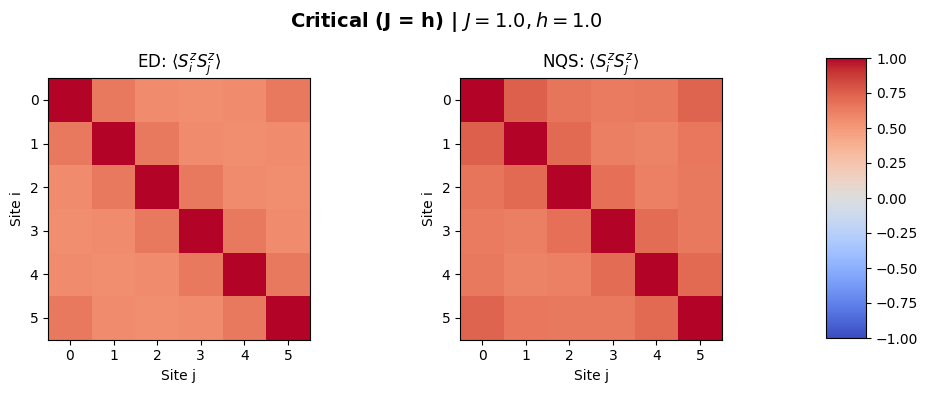

Magnetization <Sz> -> ED: -0.0000 | NQS: 0.0883
Transverse <Sx>    -> ED: 0.6440 | NQS: 0.5752


In [35]:
L = 6  

# Define the two regimes to test
regimes = {
    "Ferromagnetic (J > h)": {"J": 3.0, "h": 1.0},
    "Paramagnetic (h > J)":  {"J": 0.3, "h": 1.0},
    "Critical (J = h)":       {"J": 1.0, "h": 1.0},
}

for name, params in regimes.items():
    J = params["J"]
    h = params["h"]
    
    print(f"\n{'='*40}")
    print(f"Simulating Regime: {name} (J={J}, h={h})")
    print(f"{'='*40}")

    # 1. Exact Diagonalization (The True Answer)
    H = build_tfim_hamiltonian(L, h, J, pbc=True)
    vals, vecs = spla.eigsh(H, k=1, which='SA')
    gs_vec = vecs[:, 0]
    sz_ed, czz_ed, sx_ed = estimate_observables_ed(gs_vec, L)

    # 2. Variational Monte Carlo 
    # We must call vmc_train again to train a NEW network for these specific J and h values.
    print("Training NQS...")
    nqs, history = vmc_train(L, J, h, pbc=True, n_iter=150, lr=5e-3)
    
    print("Estimating NQS Observables...")
    sz_nqs, czz_nqs, sx_nqs = estimate_observables_nqs(nqs, L, n_samples=2000)

    # 3. Plotting and comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(
        f"{name} | $J={J}, h={h}$",
        fontsize=14, fontweight='bold', y=0.97
    )

    im1 = ax1.imshow(czz_ed, cmap='coolwarm', vmin=-1, vmax=1)
    ax1.set_title(r"ED: $\langle S^z_i S^z_j \rangle$")
    ax1.set_xlabel(r"Site j")
    ax1.set_ylabel(r"Site i")

    im2 = ax2.imshow(czz_nqs, cmap='coolwarm', vmin=-1, vmax=1)
    ax2.set_title(r"NQS: $\langle S^z_i S^z_j \rangle$")
    ax2.set_xlabel(r"Site j")
    ax2.set_ylabel(r"Site i")
    # Add a shared colorbar
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7])
    fig.colorbar(im1, cax=cbar_ax)
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # adjust layout to make room for colorbar
    plt.show()
    
    # Print numerical comparison
    print(f"Magnetization <Sz> -> ED: {sz_ed:.4f} | NQS: {np.abs(sz_nqs):.4f}")
    print(f"Transverse <Sx>    -> ED: {sx_ed:.4f} | NQS: {np.abs(sx_nqs):.4f}")

### Comments: 

Just as the hint was suggesting it for finite systems, the ED ground state preserves the global $Z_2$ symmetry, so $\braket{S_z}_{ED}$ vanished even in the ferromagnetic regime. The NQS can still spontaneously pick one symmetry-broken sector, so $|\braket{S_z}_{NQS}|$ is often the more meaningful quantity to compare.